In [2]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

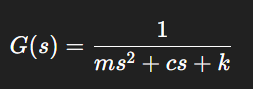

In [3]:
m = 1.0
c = 2.0
k = 5.0

sys = ct.TransferFunction([1], [m, c, k])

t, y = ct.step_response(sys)

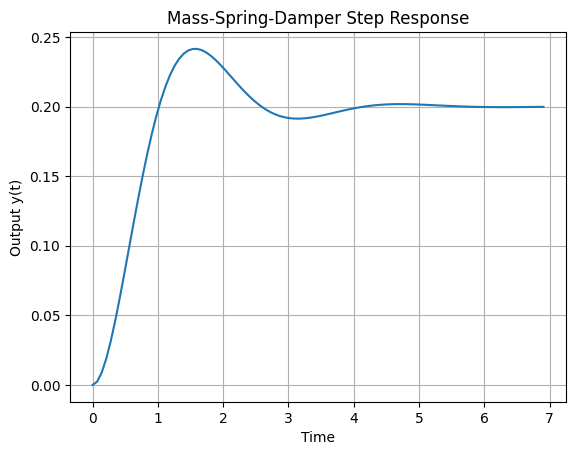

In [4]:
plt.plot(t, y)
plt.xlabel('Time')
plt.ylabel('Output y(t)')
plt.title('Mass-Spring-Damper Step Response')
plt.grid(True)
plt.show()

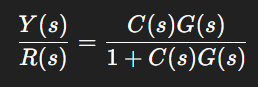

In [5]:
# =========================
# 1. Second-order plant
# G(s) = 1 / (m s^2 + c s + k)
# =========================
m = 1.0
c = 2.0
k = 5.0
G = ct.TransferFunction([1], [m, c, k])

In [6]:
# =========================
# 2. PID controller
# C(s) = Kp + Ki/s + Kd*s
#      = (Kd*s^2 + Kp*s + Ki) / s
# =========================
Kp = 10.0
Ki = 10.0
Kd = 1.0
C = ct.TransferFunction([Kd, Kp, Ki], [1, 0])

In [ ]:
# =========================
# 3. Closed-loop system
# =========================
closed_sys = ct.feedback(C * G, 1)

# =========================
# 4. Step response
# =========================
t, y = ct.step_response(closed_sys)

# =========================
# 5. Metrics calculation
# =========================
y_final = y[-1]

In [8]:
# 지표 추출
info = ct.step_info(closed_sys)

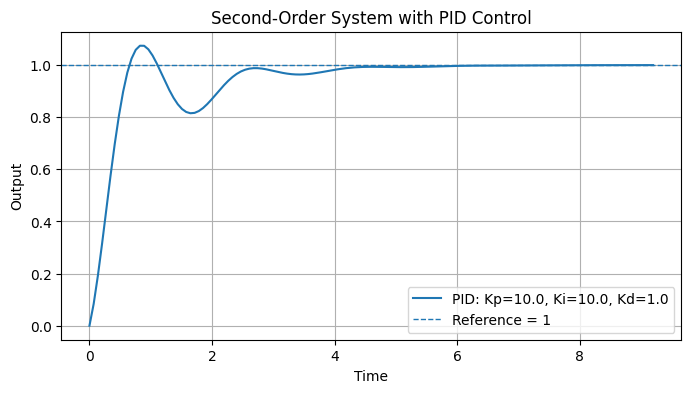

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(t, y, label=f'PID: Kp={Kp}, Ki={Ki}, Kd={Kd}')
plt.axhline(1.0, linestyle='--', linewidth=1, label='Reference = 1')
plt.xlabel('Time')
plt.ylabel('Output')
plt.title('Second-Order System with PID Control')
plt.grid(True)
plt.legend()
plt.show()

In [10]:
info

{'RiseTime': 0.48031606582989916,
 'SettlingTime': 3.9797616883048788,
 'SettlingMin': 0.8150160474443892,
 'SettlingMax': 1.0740165806237556,
 'Overshoot': 7.40165806237556,
 'Undershoot': 0,
 'Peak': 1.0740165806237556,
 'PeakTime': 0.8233989699941129,
 'SteadyStateValue': 1.0}

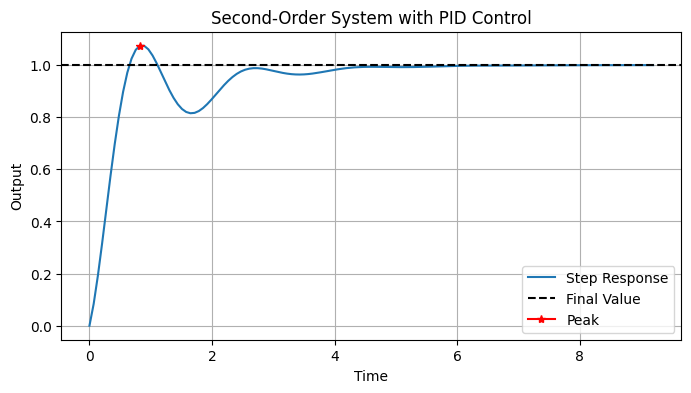

In [28]:
# =========================
# 6. Plot
# =========================
plt.figure(figsize=(8, 4))
plt.plot(t, y, label='Step Response')
plt.axhline(y_final, color='k', linestyle='--', label='Final Value')
plt.plot(info["PeakTime"], info["Peak"], color='r', marker='*', label='Peak')
plt.xlabel('Time')
plt.ylabel('Output')
plt.title('Second-Order System with PID Control')
plt.grid(True)
plt.legend()
plt.show()